/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


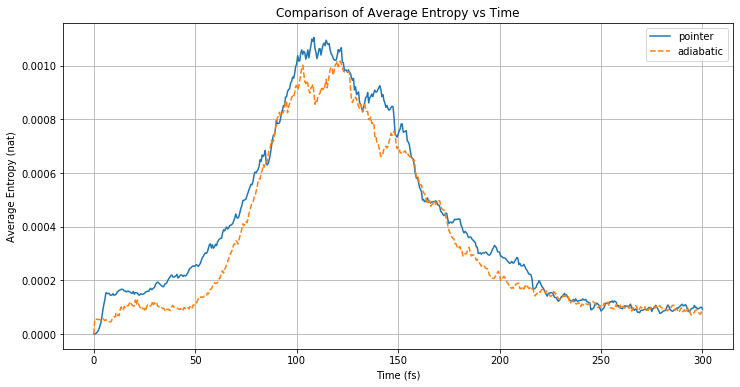

Number of files processed in Dataset 1: 100
Number of files processed in Dataset 2: 100
Time range Dataset 1: 0.0 to 300.0
Time range Dataset 2: 0.0 to 300.0
Average entropy at start (Dataset 1): 0.0
Average entropy at end (Dataset 1): 9.2897377875e-05
Average entropy at start (Dataset 2): 0.0
Average entropy at end (Dataset 2): 8.197066912500003e-05


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def process_data(directory):
    columns = ["t", "Mean-Field Energy", "PE Difference", "Total Energy", "norm", "last_column", "total count"]
    file_paths = glob.glob(os.path.join(directory, 'ene*.dat'))
    dfs = []

    for file_path in file_paths:
        df = pd.read_csv(file_path, delim_whitespace=True, names=columns, skiprows=1)
        dfs.append(df)

    combined_df = pd.concat(dfs)
    average_df = combined_df.groupby('t').mean().reset_index()
    return average_df, len(file_paths)

# Specify the paths to the directories containing the ene*.dat files
data_directory1 = '/home/adurden/Ari/TAB/9state2d/pointerC/data/'
data_directory2 = '/home/adurden/Ari/TAB/9state2d/data/'

# Process data from both directories
avg_df1, file_count1 = process_data(data_directory1)
avg_df2, file_count2 = process_data(data_directory2)

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(avg_df1['t'], (9/8)*avg_df1['last_column'], linestyle='-', label='pointer')
plt.plot(avg_df2['t'], (9/8)*avg_df2['last_column'], linestyle='--', label='adiabatic')
plt.xlabel('Time (fs)')
plt.ylabel('Average Entropy (nat)')
plt.title('Comparison of Average Entropy vs Time')
plt.legend()
plt.grid(True)
plt.savefig('entropy_comparison.pdf', format='pdf')
plt.show()
# Print some statistics
print(f"Number of files processed in Dataset 1: {file_count1}")
print(f"Number of files processed in Dataset 2: {file_count2}")
print(f"Time range Dataset 1: {avg_df1['t'].min()} to {avg_df1['t'].max()}")
print(f"Time range Dataset 2: {avg_df2['t'].min()} to {avg_df2['t'].max()}")
print(f"Average entropy at start (Dataset 1): {(9/8)*avg_df1['last_column'].iloc[0]}")
print(f"Average entropy at end (Dataset 1): {(9/8)*avg_df1['last_column'].iloc[-1]}")
print(f"Average entropy at start (Dataset 2): {(9/8)*avg_df2['last_column'].iloc[0]}")
print(f"Average entropy at end (Dataset 2): {(9/8)*avg_df2['last_column'].iloc[-1]}")

/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/opt/intel/oneapi/intelpython/latest/envs/2022.0.2/lib/python3.9/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


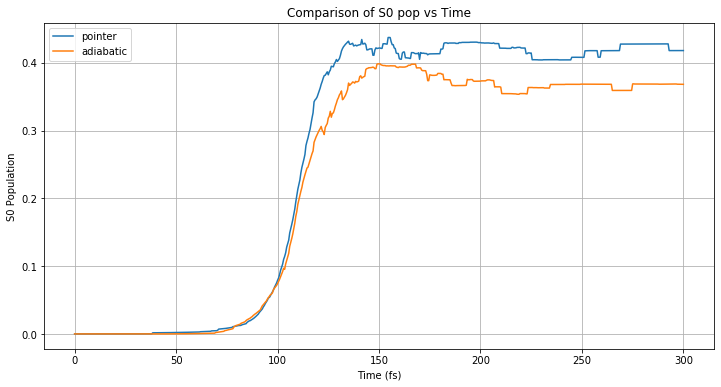

In [2]:
# Define the column names

def process_data2(directory):
    columns2 = ["t", "S0 pop", "S1 pop", "S2 pop", "S3 pop", "S4 pop", "S5 pop", "S6 pop", "S7 pop", "S8 pop", "poptot"]
    file_paths = glob.glob(os.path.join(directory, 'pop*.dat'))
    dfs = []

    for file_path in file_paths:
        df = pd.read_csv(file_path, delim_whitespace=True, names=columns2, skiprows=1)
        dfs.append(df)

    combined_df = pd.concat(dfs)
    average_df = combined_df.groupby('t').mean().reset_index()
    return average_df, len(file_paths)

avg_df1, file_count1 = process_data2(data_directory1)
avg_df2, file_count2 = process_data2(data_directory2)
# Plot the data

plt.figure(figsize=(12, 6))
plt.plot(avg_df1['t'], avg_df1['S0 pop'], label='pointer')
plt.plot(avg_df2['t'], avg_df2['S0 pop'], label='adiabatic')
plt.xlabel('Time (fs)')
plt.ylabel('S0 Population')
plt.title('Comparison of S0 pop vs Time')
plt.legend()
plt.grid(True)
plt.show()

